<a href="https://colab.research.google.com/github/almiuxcs/Ciencia_Datos/blob/main/cuaderno_inferencia_actuaria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inferencia matemática y modelos computacionales para Ciencia de Datos Actuarial

Este cuaderno reúne **teoría** y **práctica** sobre los temas centrales del módulo:

- Similitud numérica
- Correlación y causalidad
- Regresión y curvas de generalización
- Regresión lineal
- Regresión logística
- Inferencia matemática

La idea es que pueda usarse como **material de clase** y también como **práctica guiada** para estudiantes de actuaría.

---

## Objetivos de aprendizaje

Al terminar este cuaderno, el estudiante podrá:

1. Explicar para qué sirve la similitud en ciencia de datos.
2. Interpretar medidas de correlación y distinguirlas de la causalidad.
3. Comprender la idea de una curva de regresión y el problema de generalización.
4. Ajustar e interpretar modelos de regresión lineal y logística.
5. Realizar inferencia básica sobre coeficientes de regresión.
6. Relacionar los modelos con problemas actuariales como riesgo, siniestralidad y clasificación de clientes.


## 1. Preparación del entorno

En esta sección importamos librerías de uso común en ciencia de datos.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression, make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report, roc_auc_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import euclidean_distances, cosine_similarity

import statsmodels.api as sm

np.random.seed(42)

## 2. Similitud numérica

### Idea teórica

En ciencia de datos, la **similitud** sirve para medir qué tan parecidos son dos objetos, observaciones o individuos.

Si cada observación se representa como un vector de características,

$x_i=(x_{i1},x_{i2},\dots,x_{ip}),$

entonces podemos comparar dos observaciones \(x_i\) y \(x_j\) usando distintas métricas.

### Distancia euclidiana

$d(x_i,x_j)=\sqrt{\sum_{k=1}^{p}(x_{ik}-x_{jk})^2}$

Interpreta la distancia geométrica usual.

### Distancia Manhattan

$d(x_i,x_j)=\sum_{k=1}^{p}|x_{ik}-x_{jk}|$


Es útil cuando interesa acumular diferencias absolutas.

### Similitud del coseno

$
\mathrm{sim}(x_i,x_j)=\frac{x_i\cdot x_j}{\|x_i\|\|x_j\|}
$

Mide qué tan alineados están dos vectores. Se usa mucho cuando interesa la **dirección** más que la magnitud.

### ¿Para qué sirve en actuaría?

- Encontrar clientes con perfiles de riesgo similares.
- Segmentar asegurados.
- Detectar observaciones atípicas o posibles fraudes.
- Construir modelos basados en vecinos cercanos.


### Ejemplo práctico: similitud entre asegurados

Supongamos que cada cliente está descrito por:

- edad
- ingreso
- número de siniestros
- monto reclamado

Calcularemos distancias para comparar clientes.


In [ ]:
clientes = pd.DataFrame({
    "edad": [25, 28, 45, 52, 27],
    "ingreso": [25000, 27000, 60000, 65000, 25500],
    "siniestros": [0, 1, 3, 4, 0],
    "monto_reclamado": [0, 1200, 7500, 9000, 300]
}, index=["A", "B", "C", "D", "E"])

clientes

,edad,ingreso,siniestros,monto_reclamado
A,25,25000,0,0
B,28,27000,1,1200
C,45,60000,3,7500
D,52,65000,4,9000
E,27,25500,0,300


In [ ]:
dist_euclidiana = pd.DataFrame(
    euclidean_distances(clientes),
    index=clientes.index,
    columns=clientes.index
)

sim_coseno = pd.DataFrame(
    cosine_similarity(clientes),
    index=clientes.index,
    columns=clientes.index
)

print("Matriz de distancias euclidianas")
display(dist_euclidiana.round(2))

print("Matriz de similitud del coseno")
display(sim_coseno.round(4))

Matriz de distancias euclidianas


,A,B,C,D,E
A,0.00,2332.38,35794.56,41000.01,583.10
B,2332.38,0.00,33595.99,38792.27,1749.29
C,35794.56,33595.99,0.00,5220.16,35243.30
D,41000.01,38792.27,5220.16,0.00,40446.76
E,583.10,1749.29,35243.30,40446.76,0.00


Matriz de similitud del coseno


,A,B,C,D,E
A,1.0000,0.9990,0.9923,0.9905,0.9999
B,0.9990,1.0000,0.9968,0.9957,0.9995
C,0.9923,0.9968,1.0000,0.9999,0.9937
D,0.9905,0.9957,0.9999,1.0000,0.9921
E,0.9999,0.9995,0.9937,0.9921,1.0000


### Interpretación

- Si la distancia entre dos clientes es pequeña, sus perfiles son parecidos.
- Si la similitud del coseno es cercana a 1, los vectores apuntan en direcciones similares.
- En términos actuariales, esto puede ayudar a detectar grupos comparables de riesgo.

> Observación importante: antes de medir similitud suele ser necesario **escalar variables**, porque edad, ingreso y monto reclamado no están en la misma unidad.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
clientes_std = pd.DataFrame(
    scaler.fit_transform(clientes),
    index=clientes.index,
    columns=clientes.columns
)

dist_std = pd.DataFrame(
    euclidean_distances(clientes_std),
    index=clientes.index,
    columns=clientes.index
)

print("Distancias euclidianas después de estandarizar")
display(dist_std.round(2))

Distancias euclidianas después de estandarizar


,A,B,C,D,E
A,0.00,0.75,3.78,4.74,0.20
B,0.75,0.00,3.15,4.09,0.67
C,3.78,3.15,0.00,1.01,3.64
D,4.74,4.09,1.01,0.00,4.60
E,0.20,0.67,3.64,4.60,0.00


## 3. Correlación y causalidad

### 3.1 Covarianza

La covarianza entre dos variables aleatorias \(X\) y \(Y\) es:

$\mathrm{Cov}(X,Y)=E[(X-\mu_X)(Y-\mu_Y)]$

Su signo indica si la relación lineal es positiva o negativa.

### 3.2 Correlación de Pearson


$\rho_{XY}=\frac{\mathrm{Cov}(X,Y)}{\sigma_X\sigma_Y}$

Toma valores entre \(-1\) y \(1\).

- $\rho\approx 1$: relación lineal positiva fuerte
- $\rho\approx -1$: relación lineal negativa fuerte
- $\rho\approx 0$: ausencia de relación lineal

### 3.3 Correlación no implica causalidad

Dos variables pueden estar correlacionadas por varias razones:

1. $X\rightarrow Y$ (causalidad directa)
2. Una variable oculta $Z$ afecta a ambas
3. Coincidencia o correlación espuria

En actuaría esto es crucial: una variable puede predecir bien, pero eso no significa que sea la causa del fenómeno.


### Ejemplo práctico: correlación entre variables

Construiremos un pequeño conjunto de datos con variables relacionadas con costo de seguro.


In [ ]:
n = 200
edad = np.random.randint(20, 70, n)
ingreso = np.random.normal(40000, 12000, n).clip(12000, 90000)
siniestros = np.random.poisson(1.5 + 0.03*(edad-20), n)
costo = 500 + 12*edad + 0.04*ingreso + 900*siniestros + np.random.normal(0, 2000, n)

df = pd.DataFrame({
    "edad": edad,
    "ingreso": ingreso,
    "siniestros": siniestros,
    "costo": costo
})

df.head()

,edad,ingreso,siniestros,costo
0,58,38064.571460,4,3508.263014
1,48,44848.610282,5,8372.011098
2,34,62634.230815,3,4028.399484
3,62,42094.933754,2,7283.651009
4,27,43090.604689,1,2925.569681


In [ ]:
corr = df.corr(numeric_only=True)
corr.round(3)

,edad,ingreso,siniestros,costo
edad,1.000,0.027,0.393,0.265
ingreso,0.027,1.000,-0.007,0.261
siniestros,0.393,-0.007,1.000,0.523
costo,0.265,0.261,0.523,1.000


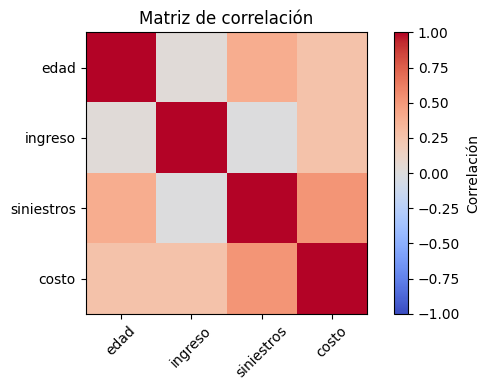

In [ ]:
plt.figure(figsize=(6,4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label="Correlación")
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

### Comentario didáctico

Es probable que `costo` aparezca correlacionado con `edad`, `ingreso` y `siniestros`. Eso sugiere relación estadística, pero no prueba causalidad por sí mismo.

Por ejemplo:

- La edad podría relacionarse con siniestralidad.
- El ingreso podría actuar como variable asociada al tipo de cobertura.
- Los siniestros influyen directamente en el costo observado.

El análisis causal requiere diseño de estudio, supuestos adicionales o métodos específicos.


## 4. Curvas de regresión y generalización

### Idea de regresión

La regresión busca modelar el valor esperado de una variable respuesta $Y$ en función de variables explicativas $X$:

$
Y = f(X) + \varepsilon
$

donde:

- $f(X)$ es la parte sistemática del modelo
- $\varepsilon$ es el error aleatorio

La **curva de regresión** es la representación de $E(Y\mid X)=f(X)$.

### Generalización

Un modelo útil no solo ajusta bien los datos observados, también debe funcionar bien con datos nuevos.

Esto lleva a distinguir entre:

- **subajuste**: el modelo es demasiado simple
- **sobreajuste**: el modelo aprende ruido en lugar de estructura
- **buena generalización**: buen equilibrio entre sesgo y varianza


### Ejemplo práctico: observar generalización con una regresión lineal

Usaremos un conjunto sintético de regresión.


In [ ]:
X, y = make_regression(
    n_samples=200, n_features=1, noise=18, random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

pred_train = modelo_lr.predict(X_train)
pred_test = modelo_lr.predict(X_test)

rmse_train = mean_squared_error(y_train, pred_train, squared=False)
rmse_test = mean_squared_error(y_test, pred_test, squared=False)

print(f"RMSE entrenamiento: {rmse_train:.2f}")
print(f"RMSE prueba: {rmse_test:.2f}")

TypeError: got an unexpected keyword argument 'squared'

In [ ]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generar datos sintéticos
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=18,
    random_state=42
)

# Separar entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

# Modelo de regresión lineal
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

# Predicciones
pred_train = modelo_lr.predict(X_train)
pred_test = modelo_lr.predict(X_test)

# Cálculo del RMSE (compatible con todas las versiones)
rmse_train = np.sqrt(mean_squared_error(y_train, pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, pred_test))

print(f"RMSE entrenamiento: {rmse_train:.2f}")
print(f"RMSE prueba: {rmse_test:.2f}")

RMSE entrenamiento: 17.66
RMSE prueba: 19.76


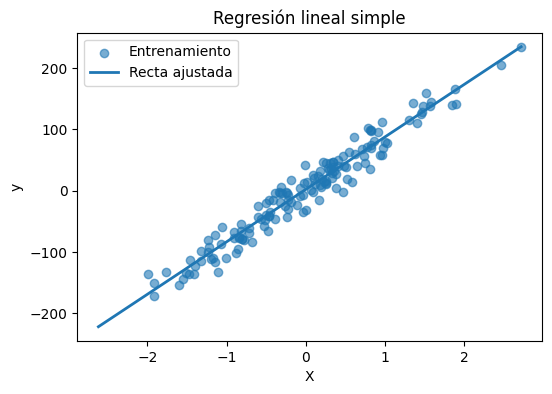

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, alpha=0.6, label="Entrenamiento")
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1,1)
y_line = modelo_lr.predict(x_line)
plt.plot(x_line, y_line, linewidth=2, label="Recta ajustada")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Regresión lineal simple")
plt.legend()
plt.show()

### Curva de aprendizaje

La curva de aprendizaje permite observar cómo cambia el error al aumentar el tamaño de muestra.


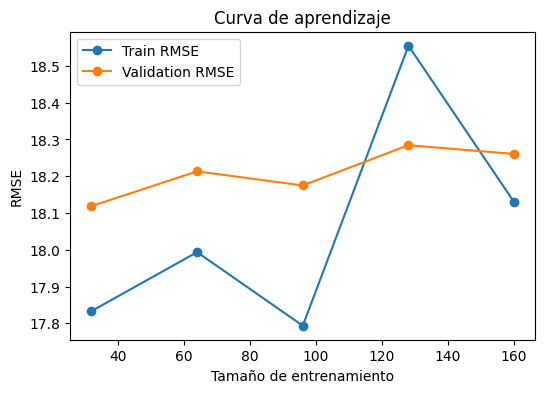

In [ ]:
train_sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X, y, cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.2, 1.0, 5)
)

train_rmse = -train_scores.mean(axis=1)
test_rmse = -test_scores.mean(axis=1)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_rmse, marker="o", label="Train RMSE")
plt.plot(train_sizes, test_rmse, marker="o", label="Validation RMSE")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("RMSE")
plt.title("Curva de aprendizaje")
plt.legend()
plt.show()

## 5. Regresión lineal

### Modelo

La regresión lineal múltiple se escribe como:

\[
Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \varepsilon
\]

donde:

- \(\beta_0\) es el intercepto
- \(\beta_j\) mide el cambio esperado en \(Y\) por una unidad adicional de \(X_j\), manteniendo las demás variables constantes

### Estimación por mínimos cuadrados

Los coeficientes se obtienen minimizando

\[
S(\beta)=\sum_{i=1}^{n}(y_i-\hat y_i)^2
\]

y en forma matricial:

\[
\hat\beta = (X^TX)^{-1}X^Ty
\]

### Supuestos clásicos

1. Linealidad en los parámetros
2. Independencia de errores
3. Varianza constante de errores
4. Normalidad de errores para pruebas e intervalos
5. No multicolinealidad severa


### Ejemplo práctico: costo de seguro como variable continua

Ajustaremos una regresión lineal al conjunto `df`.


In [ ]:
X_reg = df[["edad", "ingreso", "siniestros"]]
y_reg = df["costo"]

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.25, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

pred = reg.predict(X_test)

print("Intercepto:", round(reg.intercept_, 2))
print("Coeficientes:")
for nombre, coef in zip(X_reg.columns, reg.coef_):
    print(f"  {nombre}: {coef:.4f}")

print("\nRMSE:", round(mean_squared_error(y_test, pred, squared=False), 2))
print("R^2:", round(r2_score(y_test, pred), 4))

Intercepto: 298.06
Coeficientes:
  edad: 10.7327
  ingreso: 0.0497
  siniestros: 791.6562


TypeError: got an unexpected keyword argument 'squared'

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Variables explicativas y variable objetivo
X_reg = df[["edad", "ingreso", "siniestros"]]
y_reg = df["costo"]

# División entrenamiento / prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg,
    test_size=0.25,
    random_state=42
)

# Ajuste del modelo
reg = LinearRegression()
reg.fit(X_train, y_train)

# Predicción
pred = reg.predict(X_test)

# Resultados del modelo
print("Intercepto:", round(reg.intercept_, 2))

print("Coeficientes:")
for nombre, coef in zip(X_reg.columns, reg.coef_):
    print(f"  {nombre}: {coef:.4f}")

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("\nRMSE:", round(rmse, 2))
print("R^2:", round(r2_score(y_test, pred), 4))

Intercepto: 298.06
Coeficientes:
  edad: 10.7327
  ingreso: 0.0497
  siniestros: 791.6562

RMSE: 2237.01
R^2: 0.1993


### Interpretación actuarial de coeficientes

- El coeficiente de `edad` indica cuánto cambia el costo esperado al aumentar un año de edad, manteniendo constantes ingreso y siniestros.
- El coeficiente de `ingreso` mide el efecto marginal del ingreso.
- El coeficiente de `siniestros` suele tener una interpretación especialmente clara: a mayor número de siniestros, mayor costo esperado.


## 6. Regresión logística

### Idea teórica

Cuando la variable respuesta es binaria, la regresión lineal no es adecuada porque puede producir probabilidades fuera de \([0,1]\). Para ello se utiliza la regresión logística.

Sea \(Y\in\{0,1\}\). Entonces:

\[
P(Y=1\mid X)=\frac{1}{1+e^{-z}}
\]

con

\[
z=\beta_0+\beta_1X_1+\cdots+\beta_pX_p
\]

### Transformación logit

\[
\log\left(\frac{p}{1-p}\right)=\beta_0+\beta_1X_1+\cdots+\beta_pX_p
\]

Cada \(\beta_j\) representa el cambio en el **logaritmo de las odds** por unidad adicional de \(X_j\).

Además,

\[
e^{\beta_j}
\]

se interpreta como un **odds ratio**.


### Ejemplo práctico: clasificación binaria

Usaremos el conjunto `breast_cancer` de `sklearn` solo como ejemplo didáctico de clasificación. En un curso actuarial se puede reinterpretar como un problema de evento/no evento.


In [ ]:
data = load_breast_cancer()
X_clf = pd.DataFrame(data.data, columns=data.feature_names)
y_clf = pd.Series(data.target, name="objetivo")

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=2000))
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
proba = pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, pred), 4))
print("ROC AUC:", round(roc_auc_score(y_test, proba), 4))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, pred))

In [ ]:
print(classification_report(y_test, pred))

### Interpretación

La regresión logística es muy útil en actuaría para modelar eventos como:

- ocurrencia de siniestro
- incumplimiento de pago
- cancelación de póliza
- fraude sí/no

La salida principal es una **probabilidad estimada**.


## 7. Inferencia matemática

### Propósito

La inferencia matemática permite pasar de la muestra a conclusiones sobre la población o sobre los parámetros del modelo.

En regresión, interesa responder preguntas como:

- ¿el coeficiente asociado a una variable es distinto de cero?
- ¿qué tan precisa es la estimación?
- ¿cuál es el intervalo plausible para el parámetro?

### Prueba de hipótesis para un coeficiente

Para un coeficiente \(\beta_j\):

\[
H_0: \beta_j=0
\]

\[
H_1: \beta_j\neq 0
\]

Se usa un estadístico tipo t:

\[
t = \frac{\hat\beta_j}{SE(\hat\beta_j)}
\]

Si el valor p es pequeño, se rechaza \(H_0\) y se concluye que la variable aporta evidencia estadística.

### Intervalo de confianza

Un intervalo típico es:

\[
\hat\beta_j \pm t_{\alpha/2}SE(\hat\beta_j)
\]

Si el intervalo no contiene a cero, eso respalda la relevancia estadística del coeficiente.


### Ejemplo práctico con `statsmodels`

`statsmodels` es útil porque entrega un resumen estadístico completo.


In [ ]:
X_sm = sm.add_constant(X_reg)
modelo_sm = sm.OLS(y_reg, X_sm).fit()
print(modelo_sm.summary())

### Qué observar en el resumen

1. **coef**: estimación del parámetro.
2. **std err**: error estándar.
3. **t**: estadístico de prueba.
4. **P>|t|**: valor p.
5. **[0.025, 0.975]**: intervalo de confianza al 95%.

En un contexto actuarial, este resumen ayuda a justificar si una variable debe incluirse en un modelo de tarificación o predicción de riesgo.


## 8. Discusión conceptual: correlación, predicción e inferencia

Es importante separar tres ideas:

### a) Asociación
Describe si dos variables se mueven juntas. Aquí entran covarianza y correlación.

### b) Predicción
Busca construir modelos que anticipen resultados futuros con el menor error posible.

### c) Causalidad
Busca responder si una variable provoca cambios en otra.

Un modelo predictivo puede ser muy bueno sin ser causal. Y una relación causal puede ser difícil de identificar solo con datos observacionales.


## 9. Ejercicios propuestos

### Ejercicio 1. Similitud
Estandariza las variables de `clientes` y responde:
- ¿qué par de clientes es más similar?
- ¿cambia la respuesta al usar distancia euclidiana y similitud del coseno?

### Ejercicio 2. Correlación
En el conjunto `df`:
- calcula la correlación entre todas las variables
- identifica la variable más relacionada con `costo`
- explica por qué esa correlación no implica causalidad por sí sola

### Ejercicio 3. Regresión lineal
Ajusta un modelo usando solo `edad` e `ingreso`.
- compara el RMSE con el modelo que incluye `siniestros`
- interpreta los coeficientes

### Ejercicio 4. Regresión logística
Con el conjunto de clasificación:
- cambia el umbral de decisión de 0.5 a 0.7
- observa qué ocurre con falsos positivos y falsos negativos

### Ejercicio 5. Inferencia
En el resumen de `statsmodels`:
- identifica qué variables tienen valor p menor a 0.05
- escribe una conclusión en lenguaje actuarial


## 10. Conclusión

Este cuaderno mostró que:

- la **similitud** permite comparar y segmentar observaciones;
- la **correlación** resume asociación lineal, pero no demuestra causalidad;
- la **regresión** modela relaciones entre variables;
- la **regresión lineal** se usa para respuestas continuas;
- la **regresión logística** se usa para respuestas binarias;
- la **inferencia matemática** permite evaluar la significancia y precisión de los parámetros.

En ciencia de datos actuarial, estas herramientas forman una base sólida para tareas de clasificación de riesgo, estimación de costos, tarificación y análisis de siniestralidad.


## 11. Bibliografía sugerida

1. Casella, G. y Berger, R. *Statistical Inference*.
2. Wackerly, D., Mendenhall, W. y Scheaffer, R. *Mathematical Statistics with Applications*.
3. Montgomery, D., Peck, E. y Vining, G. *Introduction to Linear Regression Analysis*.
4. Kutner, M., Nachtsheim, C., Neter, J. y Li, W. *Applied Linear Statistical Models*.
5. James, G., Witten, D., Hastie, T. y Tibshirani, R. *An Introduction to Statistical Learning*.
6. Hastie, T., Tibshirani, R. y Friedman, J. *The Elements of Statistical Learning*.
7. Frees, E. *Regression Modeling with Actuarial and Financial Applications*.
